In [31]:
import pandas as pd
from pathlib import Path
import numpy as np

dir_path = Path().cwd()

df = pd.read_csv( dir_path / 'Stars.csv')

main_trace = df[df['Star type'] == 3]

# np.random.seed(0)
shuffled_idx = np.random.permutation(main_trace.index)
split_idx = len(shuffled_idx) // 2

divided_trace_1 = main_trace.loc[shuffled_idx[:split_idx]].reset_index(drop=True)
divided_trace_2 = main_trace.loc[shuffled_idx[split_idx:]].reset_index(drop=True)

display(divided_trace_1)
display(divided_trace_2)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,6757,1.430,1.120,2.410,3,yellow-white,F
1,25070,14500.000,5.920,-3.980,3,Blue-white,B
2,36108,198000.000,10.200,-4.400,3,Blue,O
3,32460,173800.000,6.237,-4.360,3,Blue,O
4,5936,1.357,1.106,4.460,3,yellow-white,F
5,19400,10920.000,6.030,-3.080,3,Blue-white,B
6,4526,0.153,0.865,6.506,3,yellowish,K
7,30000,28840.000,6.300,-4.200,3,Blue-white,B
8,13023,998.000,6.210,-1.380,3,Blue-white,A
9,6380,1.350,0.980,2.930,3,yellow-white,F


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,14060,1092.000,5.745,-2.040,3,Blue-white,A
1,28700,16790.000,6.400,-4.090,3,Blue-white,B
2,39000,204000.000,10.600,-4.700,3,Blue,O
3,17140,883.000,5.653,-2.640,3,Blue-white,B
4,5587,0.819,0.990,5.030,3,yellow-white,F
5,8052,8.700,1.800,2.420,3,Whitish,A
6,7720,7.920,1.340,2.440,3,yellow-white,F
7,5112,0.630,0.876,4.680,3,Orange-Red,K
8,37800,202900.000,6.860,-4.560,3,Blue,O
9,8945,38.000,2.487,0.120,3,Blue-White,A


# Full Dataset

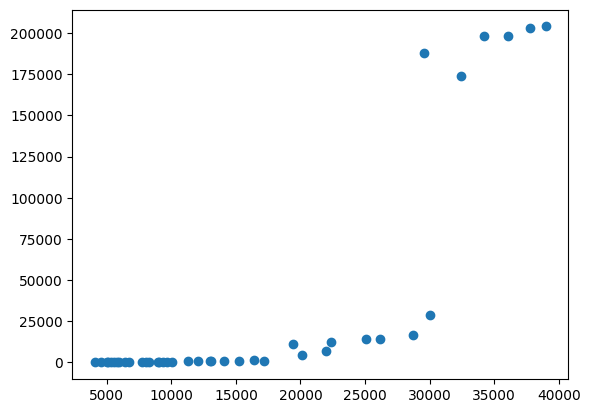

In [23]:
import matplotlib.pyplot as plt


plt.scatter( main_trace['Temperature (K)'].to_numpy() , main_trace['Luminosity(L/Lo)'].to_numpy())

# plt.xscale('log')
# plt.yscale('log')

[2.39470749 3.24409411]
[ 2.59629835  3.28396849 -0.56000506]
[ 2.59586707  3.22163426 -0.56482762  0.09943837]
[ 2.72277981  3.24975912 -1.76039384  0.019998    1.34617737]
[ 2.71764004  3.03025846 -1.74916571  0.96842006  1.34986575 -0.80942393]
[ 2.87907018  3.0071898  -4.90548064  1.04014444 10.11953983 -0.85845888
 -6.01836606]
[ 2.8785175   2.71836158 -4.96387133  3.61830293 10.30956815 -6.34724503
 -6.14656202  3.25762494]
[  2.90210654   2.69716579  -5.75279184   3.71692239  14.492524
  -6.46840798 -13.18409156   3.30800956   3.64960312]


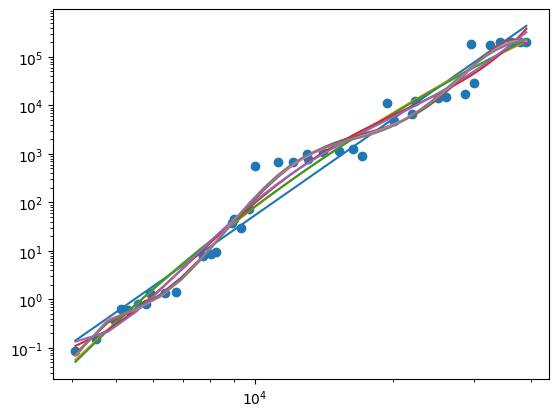

In [24]:

from numpy.polynomial import Polynomial

y = main_trace['Luminosity(L/Lo)'].to_numpy()
x = main_trace['Temperature (K)'].to_numpy()

x_fit = np.linspace( min(x) , max(x))

l_models = []


for i in range( 1 , 9):
    p = Polynomial.fit(np.log10(x), np.log10(y), i)
    l_models.append(p)
    print(p.coef)
    plt.plot(x_fit, 10 ** p(np.log10(x_fit)))




plt.scatter(x, y)
plt.xscale('log')
plt.yscale('log')
plt.show()


In [25]:
from scipy.stats import norm
def NLL(x_data , y_data, model):
    return -np.sum( norm.logpdf((10**model(np.log10(x_data)) - y_data)))

def MSE(x_data , y_data , model):
    return np.mean((y_data-10**model(np.log10(x_data)))**2)

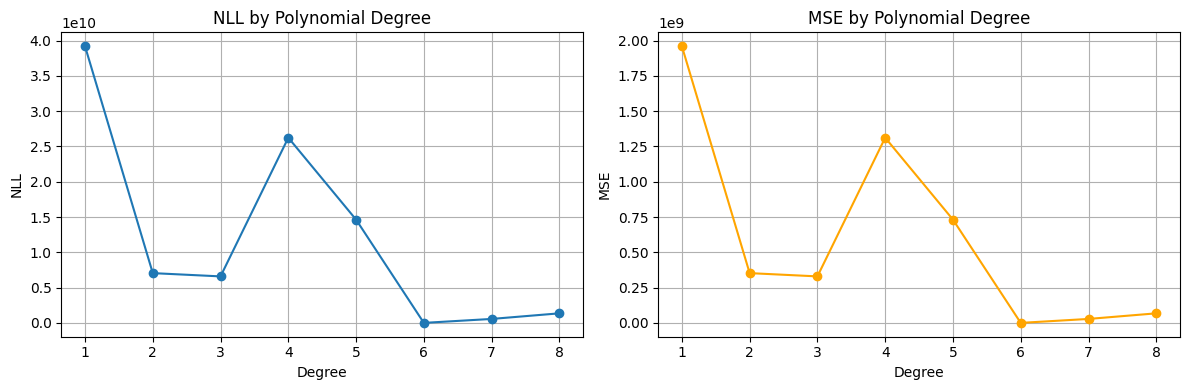

In [26]:
nll_score = []
mse_score = []

for p in l_models:
    nll_score.append( NLL(x, y , p))
    mse_score.append( MSE(x , y , p))

nll_min = np.argmin(nll_score)
mse_min = np.argmin(mse_score)

nll_score = [ score - nll_score[nll_min] for score in nll_score]
mse_score = [ score - mse_score[mse_min] for score in mse_score]


degrees = range(1, len(l_models) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(degrees, nll_score, marker='o')
ax[0].set_title('NLL by Polynomial Degree')
ax[0].set_xlabel('Degree')
ax[0].set_ylabel('NLL')
ax[0].grid(True)

ax[1].plot(degrees, mse_score, marker='o', color='orange')
ax[1].set_title('MSE by Polynomial Degree')
ax[1].set_xlabel('Degree')
ax[1].set_ylabel('MSE')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Divided Dataset

[2.28292167 3.08888484]
[ 2.4309439   3.12273625 -0.37288435]
[ 2.45044221  2.80520935 -0.40857667  0.45907573]
[ 2.57891495  2.9358787  -1.6322058   0.29233991  1.29841367]
[ 2.57860998  2.99944479 -1.62727152  0.03261672  1.29346092  0.21041798]
[ 2.69443598  3.10495954 -3.96156563 -0.13912919  7.4924259   0.24635657
 -4.07336156]
[ 2.707337    2.8594274  -4.2976836   2.29068778  8.28173285 -4.97249917
 -4.52550062  3.06323149]
[ 2.6857953   2.8304646  -3.62346449  2.61927468  4.7611768  -5.68241528
  1.31473118  3.46516891 -2.98329919]


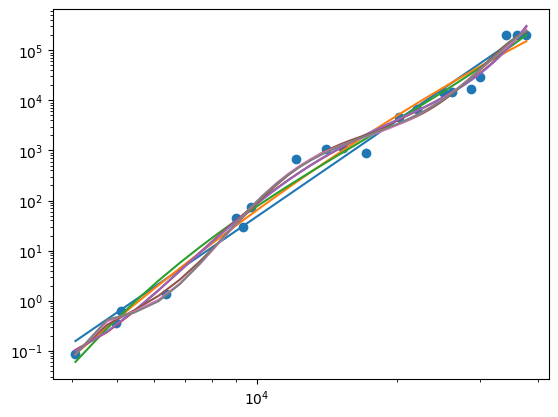

In [27]:
from numpy.polynomial import Polynomial

y = divided_trace_1['Luminosity(L/Lo)'].to_numpy()
x = divided_trace_1['Temperature (K)'].to_numpy()

x_fit = np.linspace( min(x) , max(x))

l_models = []


for i in range( 1 , 9):
    p = Polynomial.fit(np.log10(x), np.log10(y), i)
    l_models.append(p)
    print(p.coef)
    plt.plot(x_fit, 10 ** p(np.log10(x_fit)))




plt.scatter(x, y)
plt.xscale('log')
plt.yscale('log')
plt.show()


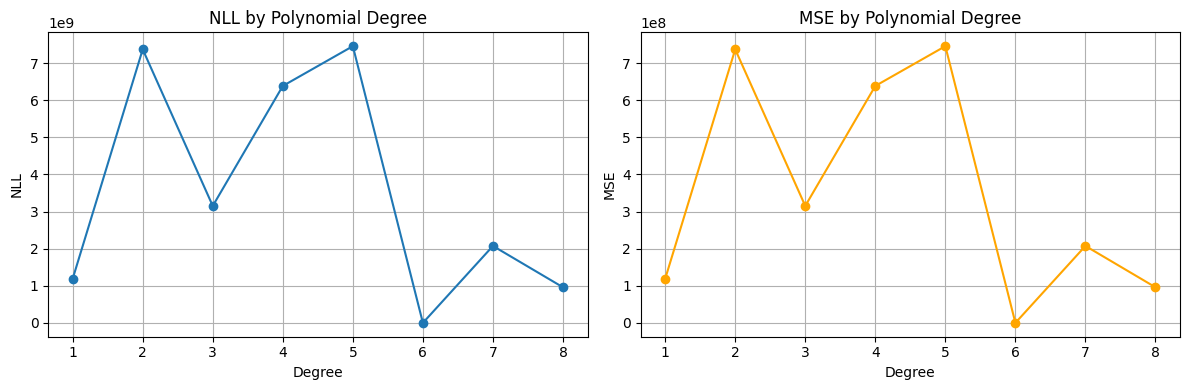

In [28]:
nll_score = []
mse_score = []

for p in l_models:
    nll_score.append( NLL(x, y , p))
    mse_score.append( MSE(x , y , p))

nll_min = np.argmin(nll_score)
mse_min = np.argmin(mse_score)

nll_score = [ score - nll_score[nll_min] for score in nll_score]
mse_score = [ score - mse_score[mse_min] for score in mse_score]


degrees = range(1, len(l_models) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(degrees, nll_score, marker='o')
ax[0].set_title('NLL by Polynomial Degree')
ax[0].set_xlabel('Degree')
ax[0].set_ylabel('NLL')
ax[0].grid(True)

ax[1].plot(degrees, mse_score, marker='o', color='orange')
ax[1].set_title('MSE by Polynomial Degree')
ax[1].set_xlabel('Degree')
ax[1].set_ylabel('MSE')
ax[1].grid(True)

plt.tight_layout()
plt.show()

definitive_model = l_models[5]

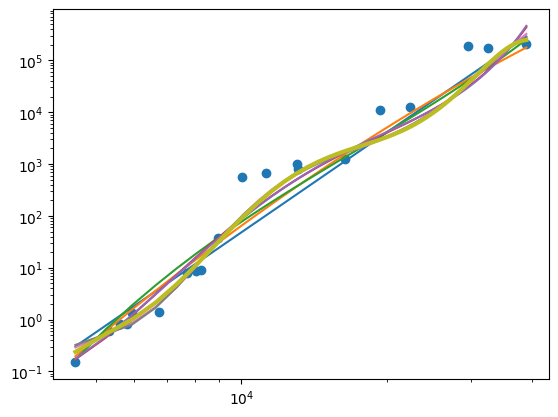

In [29]:
from numpy.polynomial import Polynomial

y = divided_trace_2['Luminosity(L/Lo)'].to_numpy()
x = divided_trace_2['Temperature (K)'].to_numpy()

x_fit = np.linspace( min(x) , max(x))

for p in l_models:
    plt.plot(x_fit, 10 ** p(np.log10(x_fit)))

plt.plot(x_fit, 10 ** definitive_model(np.log10(x_fit)), linewidth=3)




plt.scatter(x, y)
plt.xscale('log')
plt.yscale('log')
plt.show()

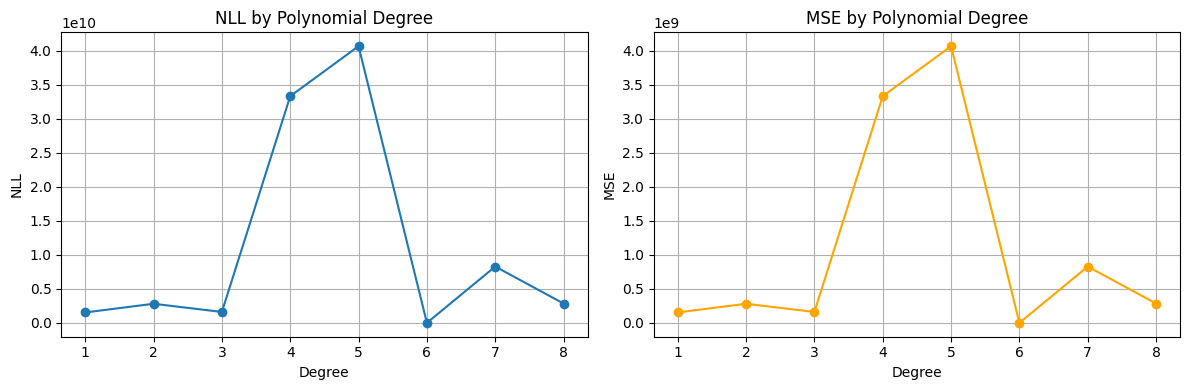

6 6


In [33]:
y = divided_trace_2['Luminosity(L/Lo)'].to_numpy()
x = divided_trace_2['Temperature (K)'].to_numpy()

nll_score = []
mse_score = []

for p in l_models:
    nll_score.append( NLL(x, y , p))
    mse_score.append( MSE(x , y , p))

nll_min = np.argmin(nll_score)
mse_min = np.argmin(mse_score)

nll_score = [ score - nll_score[nll_min] for score in nll_score]
mse_score = [ score - mse_score[mse_min] for score in mse_score]


degrees = range(1, len(l_models) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(degrees, nll_score, marker='o')
ax[0].set_title('NLL by Polynomial Degree')
ax[0].set_xlabel('Degree')
ax[0].set_ylabel('NLL')
ax[0].grid(True)

ax[1].plot(degrees, mse_score, marker='o', color='orange')
ax[1].set_title('MSE by Polynomial Degree')
ax[1].set_xlabel('Degree')
ax[1].set_ylabel('MSE')
ax[1].grid(True)

plt.tight_layout()
plt.show()

print( nll_min + 1 , mse_min + 1)